# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the `Materials and Methods` section of the paper, 17 marketing campaigns are represented by the data. These 17 campaigns ran between May 2008 and November 2010, and have a total of 79,354 contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### EDA

Let's take a closer look at some of the features we will be further examining.

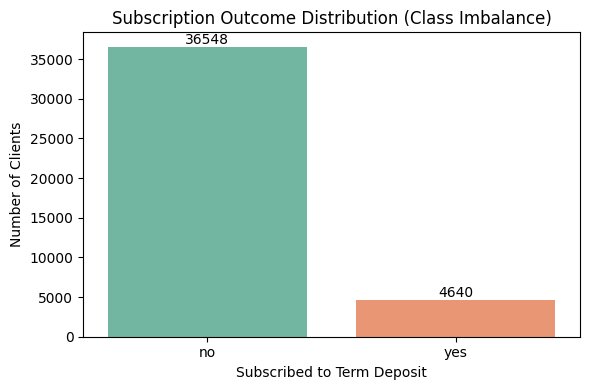

In [5]:
# Looking at target variable
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False)
plt.title('Subscription Outcome Distribution (Class Imbalance)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Clients')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Heavy class imbalance is present, with the large majority of clients not subscribing to the term deposit. Looking closer at the numbers, `36,548` people said no, while only `4,640` said yes, meaning about 88.7% of all clients did not subscribe.

Next, we look at the age distribution to understand the general age range of clients in this dataset.

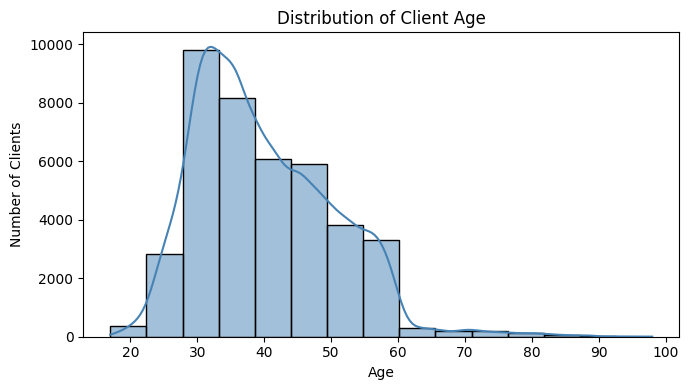

In [6]:
# Looking at client age range
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='age', bins=15, kde=True, color='steelblue')
plt.title('Distribution of Client Age')
plt.xlabel('Age')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()

The age distribution is right-skewed, with the bulk of clients concentrated between roughly 25 and 60 years old, and a peak around the early 30s where the count approaches nearly 10,000 clients. After age 60, the number of clients drops off sharply, with only a small, thinning tail extending out toward 90-100. This suggests the bank's client base, or at least the clients being contacted in these campaigns, skews toward working-age adults, with relatively few older retirees represented.

Next, we look at job type, marital status, and education level. Since these are all categorical features describing different aspects of a client's background, we group them into a single set of three smaller charts rather than giving each its own section, making it easier to compare their distributions side by side.

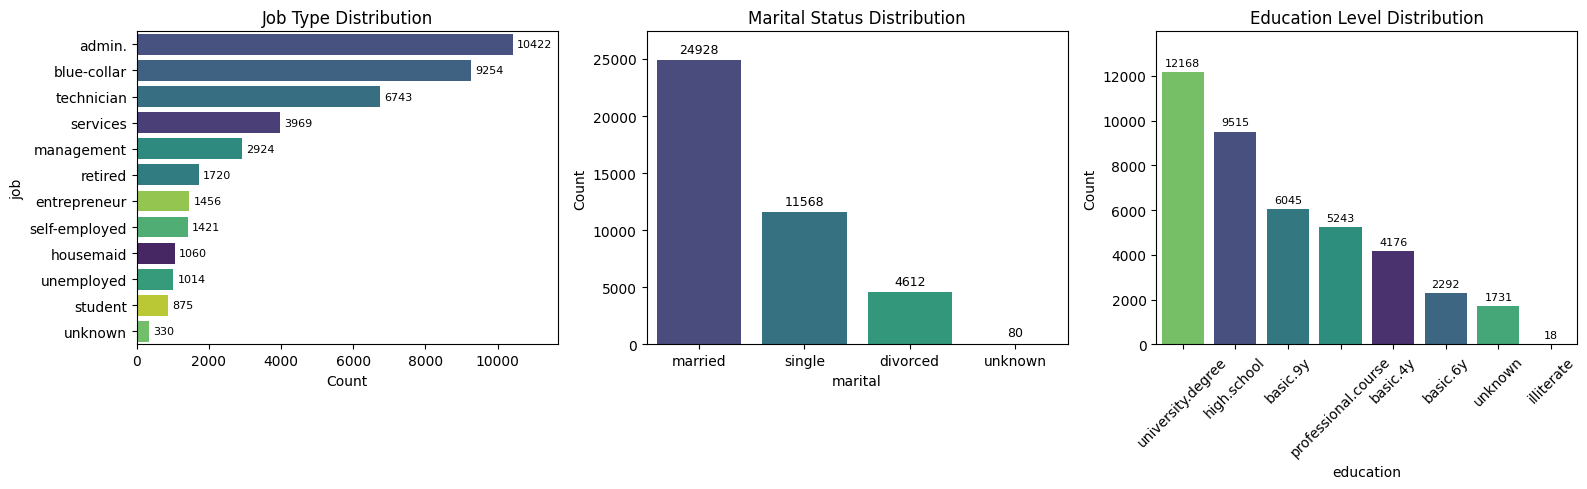

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Looking at job distribution
ax0 = sns.countplot(data=df, y='job', hue='job', order=df['job'].value_counts().index, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Job Type Distribution')
axes[0].set_xlabel('Count')
axes[0].margins(x=0.12)
for container in ax0.containers:
    axes[0].bar_label(container, fontsize=8, padding=3)

# Looking at marital status
ax1 = sns.countplot(data=df, x='marital', hue='marital', order=df['marital'].value_counts().index, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Marital Status Distribution')
axes[1].set_ylabel('Count')
axes[1].margins(y=0.1)
for container in ax1.containers:
    axes[1].bar_label(container, fontsize=9, padding=3)

# Looking at education levels
ax2 = sns.countplot(data=df, x='education', hue='education', order=df['education'].value_counts().index, ax=axes[2], palette='viridis', legend=False)
axes[2].set_title('Education Level Distribution')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('Count')
axes[2].margins(y=0.15)
for container in ax2.containers:
    axes[2].bar_label(container, fontsize=8, padding=3)
    
plt.tight_layout()
plt.show()

##### Job Type
Admin. is the most common job type, with just over 10,000 clients, followed by blue-collar (roughly 9,200) and technician (roughly 6,700). These three categories alone account for the majority of clients. On the other end, unknown, student, and unemployed are the least represented, each with under 1,000 clients. This suggests the dataset skews toward clients with established, working-age occupations rather than students or those between jobs.

##### Marital Status
Married clients make up the clear majority, at roughly 25,000, more than double the next largest group, single, at around 11,500. Divorced clients account for a smaller share, around 4,600, and unknown is negligible. This lines up with the age distribution seen earlier, where clients cluster heavily in the 25-60 range, an age range where marriage is more common.

##### Education Level
University degree is the most common education level, at just over 12,000 clients, followed closely by high school, at around 9,500. Basic education levels (9y, 6y, 4y) and professional course are more evenly spread in the middle range, while unknown and illiterate are the smallest categories, with illiterate barely visible on the chart. Overall, the client base leans toward more educated individuals, with relatively few clients falling into the lowest education categories.

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



Several categorical columns (job, marital, education, default, housing, loan) use "unknown" as a value instead of a proper null. This functions as a missing value encoding rather than a real category, and needs a decision on whether to drop those rows or keep "unknown" as its own category.

The pdays column uses 999 as a placeholder for "not previously contacted." Left as is, a model would treat 999 as a real numeric value rather than a stand-in, skewing any distance-based or regression-based calculation. This needs either a recode or a separate flag column marking whether a client was previously contacted.

Most of the categorical columns (job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome) need to be converted to numeric form before a classifier can use them, typically through one-hot encoding. Education is an exception, since its categories have a natural order and can be encoded ordinally instead. The target column y also needs conversion, from 'yes'/'no' text to 0/1.

The duration column is numeric already, but the data description notes it leaks the outcome, since a duration of 0 always corresponds to y='no', and duration isn't known until after a call ends. For a realistic predictive model, this column should be dropped rather than kept.

The remaining numeric columns appear fine and only need a dtype check after loading the data.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

The business objective is to predict, before a call is made, whether a client is likely to subscribe to a term deposit, using client demographics, financial attributes, and prior campaign history. This allows the bank to prioritize outreach toward clients with a higher likelihood of subscribing, improving the efficiency of future marketing campaigns and reducing the cost of unproductive contacts.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

First, we must identify which features need to be changed. Since we are only working with the bank information features for now, we will only look at the `age`,`job`,`marital`,`education`,`default`,`housing`, and `loan` columns.

`Age` stays numerical as is, no transformation needed there.

`Job` and `marital` are nominal categories with no inherent order, so they get one-hot encoded. Each includes an "unknown" value, which just becomes its own column like any other category at this stage.

`Education` has a natural order (basic.4y through university.degree), so it's a candidate for ordinal encoding rather than one-hot.

`default`, `housing`, and `loan` are technically binary (yes/no) but include "unknown" as a third value, so they aren't purely binary. One-hot encoding handles this cleanly without forcing a false binary structure.

`y` is the target and gets mapped to 0/1.

In [9]:
# Only taking the bank information features
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = df[bank_features].copy()
y = df['y'].map({'no': 0, 'yes': 1})

# Ordinal encoding for education, since categories have a natural order
education_order = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': -1  # flagged separately since it doesn't fit the order
}
X['education'] = X['education'].map(education_order)

# One-hot encoding for the remaining nominal categorical columns
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [11]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_accuracy = baseline.score(X_test, y_test)
print(baseline_accuracy)

0.8875940762320952


As shown in the class balance chart during the exploratory data analysis section, only a small share of clients subscribed to a term deposit, which lines up with the baseline calculated above.

The baseline performance comes from always predicting the majority class, since that sets the minimum bar any real model needs to beat.

Using a DummyClassifier with the most_frequent strategy, this baseline comes out to 0.8876. About 88.8% of clients in the dataset did not subscribe to a term deposit, so any of the four classifiers needs to clear roughly 88.76% accuracy to be considered better than guessing "no" every time.

This bar is easy to clear numerically but harder to clear in a meaningful way. A model could land around 89-90% accuracy by leaning toward "no" predictions while still missing most actual subscribers. Given this class imbalance, accuracy alone should be interpreted carefully going forward, since a high score doesn't necessarily mean the model is good at identifying actual subscribers, only that it agrees with the majority outcome most of the time.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [12]:
logreg = LogisticRegression(max_iter=1000,random_state=42)
logreg.fit(X_train, y_train)
logreg_accuracy = logreg.score(X_test, y_test)

### Problem 9: Score the Model

What is the accuracy of your model?

In [13]:
print(logreg_accuracy)

0.8875940762320952


This matches the baseline accuracy of 0.8876, meaning the initial model using only bank client features didn't outperform simply predicting the majority class

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [14]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42))
    ])
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

results_df = pd.DataFrame(results)

In [15]:
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.061138,0.887239,0.887594
1,KNN,0.034415,0.889216,0.878449
2,Decision Tree,0.103897,0.917970,0.863640
3,SVM,29.419652,0.887239,0.887594


Across the three models shown, SVM achieved the best test accuracy (0.8876), narrowly ahead of KNN (0.8784) and Decision Tree (0.8636), but its train time (29.42s) was dramatically higher than KNN (0.03s) and Decision Tree (0.10s), making it the least efficient choice for the marginal accuracy gain. Decision Tree also shows a notable gap between train accuracy (0.9180) and test accuracy (0.8636), suggesting some overfitting to the training data. 

Importantly, none of these models meaningfully outperform the baseline accuracy of 0.8876 established earlier, indicating that the bank client features alone (age, job, marital status, education, default, housing, loan) don't carry enough predictive signal to beat simply guessing the majority class. This suggests the campaign-related and economic context features excluded at this stage may be necessary to build a model that actually adds value over the baseline.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

The first objective is to apply hyperparameter tuning through grid search across all four models. This lets us see whether adjusting each model's parameters, such as the number of neighbors in KNN, the regularization strength in Logistic Regression and SVM, or the maximum depth in the Decision Tree, leads to any meaningful improvement over the default settings used earlier.

In [16]:
param_grids = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 7, 9, 11]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 10, None]}
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
        {'clf__C': [0.1, 1, 10]}
    )
}

tuned_results = []
for name, (model, params) in param_grids.items():
    start = time.time()
    grid = GridSearchCV(model, params, scoring='accuracy', cv=5)
    grid.fit(X_train, y_train)
    train_time = time.time() - start
    test_acc = grid.score(X_test, y_test)
    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Train Time': train_time,
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy': test_acc
    })

tuned_results_df = pd.DataFrame(tuned_results)

In [17]:
tuned_results_df

,Model,Best Params,Train Time,Best CV Accuracy,Test Accuracy
0,Logistic Regression,{'clf__C': 0.01},1.443869,0.887239,0.887594
1,KNN,{'clf__n_neighbors': 11},6.373049,0.884950,0.884033
2,Decision Tree,{'max_depth': 5},1.233955,0.886997,0.887756
3,SVM,{'clf__C': 0.1},430.626823,0.887239,0.887594


All four tuned models land within a narrow band, between 0.884 and 0.888 test accuracy, and all sit close to the baseline of 0.8876. Logistic Regression and SVM both match the baseline almost exactly at 0.887594, Decision Tree comes close behind at 0.887756, and KNN trails slightly at 0.884033. None of these represent a meaningful improvement over simply predicting "no" for every client.

Train time varies a lot across the four models despite this similarity in accuracy. SVM took 430.63 seconds to train, over 7 minutes, while the other three finished in under 7 seconds. For that much extra computation, SVM produced the same test accuracy as Logistic Regression, which trained in 1.44 seconds. That makes SVM hard to justify for this feature set.

Logistic Regression's best-performing regularization strength (C=0.01) is quite small, meaning stronger regularization worked best. This usually suggests the model is compensating for weak signal in the features rather than finding much real structure to fit.

Hyperparameter tuning did not meaningfully improve any of the four models beyond the baseline. This backs up the earlier finding that the bank client demographic features alone (age, job, marital status, education, default, housing, loan) do not carry enough predictive signal for this task. The more useful next step would be adding the campaign-related and economic context features excluded at this stage, rather than tuning further within this limited feature set.

Before we start modeling with the new features, we first have to clean and encode them so they are ready for modeling. We will apply the same encoding as the categories we worked with earlier in this report. Note that despite now utilizing all of the features, `duration` is still missing. This is for the same reason we removed `duration` in the earlier feature encoding.

In [18]:
full_features = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week',
    'campaign', 'pdays', 'previous', 'poutcome',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]
X = df[full_features].copy()
y = df['y'].map({'no': 0, 'yes': 1})

# pdays: create a "previously contacted" flag, then recode the 999 placeholder
X['was_contacted_before'] = (X['pdays'] != 999).astype(int)
X['pdays'] = X['pdays'].replace(999, -1)

# education: ordinal encoding, since categories have a natural order
education_order = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': -1
}
X['education'] = X['education'].map(education_order)

# remaining nominal categoricals: one-hot encoding
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

Now we can use the dataframe `X` to split into train/test sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

With the data split into training and test sets, we establish a baseline before fitting any real model, using a classifier that always predicts the majority class.

In [20]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_accuracy = baseline.score(X_test, y_test)
print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.8875940762320952


With the baseline established using the full feature set, we now move to hyperparameter tuning across all four classifiers using `GridSearchCV`, to see whether the additional campaign and economic context features allow any of the models to meaningfully outperform this baseline.

In [21]:
param_grids = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 7, 9, 11]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 10, None]}
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
        {'clf__C': [0.1, 1, 10]}
    )
}

tuned_results = []
for name, (model, params) in param_grids.items():
    start = time.time()
    grid = GridSearchCV(model, params, scoring='accuracy', cv=5)
    grid.fit(X_train, y_train)
    train_time = time.time() - start
    test_acc = grid.score(X_test, y_test)
    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Train Time': train_time,
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy': test_acc
    })


In [22]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Best Params,Train Time,Best CV Accuracy,Test Accuracy
0,Logistic Regression,{'clf__C': 0.1},4.022418,0.900177,0.901190
1,KNN,{'clf__n_neighbors': 11},9.532842,0.895182,0.895687
2,Decision Tree,{'max_depth': 5},2.735817,0.900350,0.901028
3,SVM,{'clf__C': 1},934.561267,0.898651,0.900380


All four tuned models now clear the baseline (0.8876) by 1-2.5 points, confirming that the campaign and economic context features carry predictive signal the bank client demographics alone lacked.

Logistic Regression is the standout, tying Decision Tree for the best test accuracy (0.901190 vs. 0.901028) while training in 4.02 seconds, versus SVM's 934 seconds (nearly 16 minutes) for a slightly worse result (0.900380). Decision Tree at max_depth=5 is nearly as accurate and trains fastest overall (2.74s), with tuning now controlling the overfitting seen earlier. KNN is the weakest performer (0.895687) and relatively slow (9.53s), likely struggling with the added dimensionality from one-hot encoding. SVM's runtime climbed even further from the bank-features run (430s to 934s) without producing the best accuracy, making it hard to justify.

Overall, the full feature set produced real gains over the baseline that the bank-client-only features could not, and Logistic Regression offers the best trade-off between accuracy and efficiency.

##### Answering the Business Question

Now that we have established which model would be the best, let's answer the business question. To reiterate, our business question was to predict, before a call is made, whether a client is likely to subscribe to a term deposit, using client demographics, financial attributes, and prior campaign history, so the bank can prioritize outreach toward clients with a higher likelihood of subscribing and reduce the cost of unproductive contacts.

In [23]:
best_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
best_logreg.fit(X_train, y_train)

# Coefficient interpretation
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_logreg.named_steps['clf'].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

# Probability-based ranking of clients
probs = best_logreg.predict_proba(X_test)[:, 1]
results = pd.DataFrame({'Actual': y_test.values, 'Predicted Probability': probs}).sort_values('Predicted Probability', ascending=False)
results

,Actual,Predicted Probability
2098,1,0.885021
11918,1,0.884979
7211,0,0.883523
416,1,0.874509
8414,0,0.869715
...,...,...
9271,0,0.004544
5671,0,0.004324
118,0,0.003132
9033,0,0.001218


This table ranks test set clients by predicted probability of subscribing, from most to least likely, with Actual showing whether they really subscribed (1) or not (0).

At the top, predicted probabilities exceed 0.87, and three of the five shown did subscribe, confirming the model is picking up real signal. At the bottom, probabilities sit near 0, and all shown clients did not subscribe, showing the model is also confident and correct about unlikely converters.

This ranking directly supports the business objective. Instead of contacting all 12,357 test clients equally, the bank could prioritize outreach toward the top of this list, where likely subscribers concentrate, and deprioritize the bottom, where contact is unlikely to pay off.

To understand what's actually driving these predictions, and which factors the bank could act on, we next look at the model's coefficients to see which features push clients toward or away from subscribing.

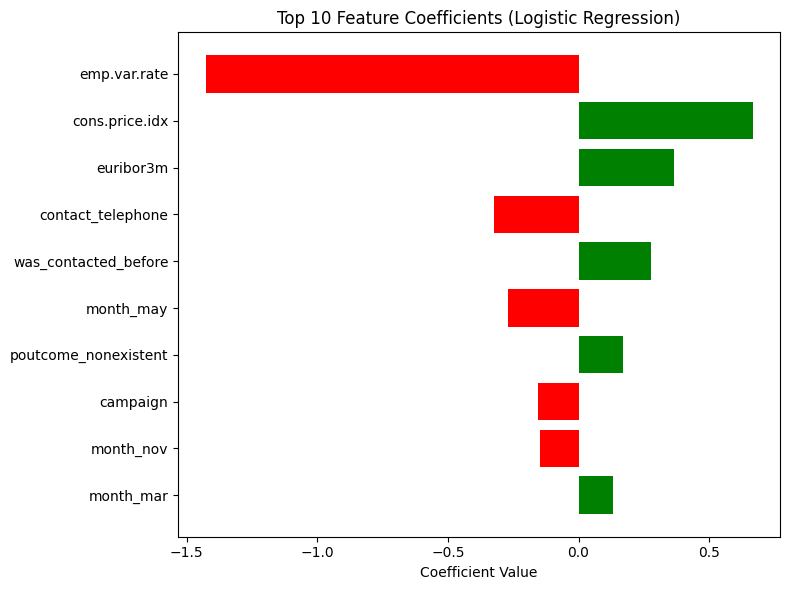

In [25]:
# Looking at top coefficients
top_coefs = coefficients.head(10)
plt.figure(figsize=(8, 6))
colors = ['green' if c > 0 else 'red' for c in top_coefs['Coefficient']]
plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The coefficient chart shows which features most strongly influence subscription likelihood, with bar direction indicating the relationship (green pushes toward "yes," red pushes toward "no") and length indicating strength.

Economic indicators dominate. `emp.var.rate` has by far the strongest effect, nearly four times larger than any other feature, and it's negative, indicating that higher employment variation pushes toward "no," likely because term deposits become less attractive when the economy is stronger. `cons.price.idx` and `euribor3m` are both positive, suggesting higher prices and interest rates make term deposits comparatively more appealing.

Contact-related features matter too. `was_contacted_before` is positive, repeat contact increases likelihood of subscribing. `contact_telephone` and `campaign` are both negative, telephone contact and more calls within the current campaign both correlate with lower subscription odds, pointing to diminishing returns from over-contacting.

Timing also shows an effect, `month_may` is negative while `month_mar` is positive, suggesting some seasonal pattern, though this warrants caution without checking contact volume per month.

While the strongest predictors are macroeconomic factors outside the bank's control, the actionable takeaways are clear: favor cellular over telephone contact, avoid repeated contacts with the same client, and consider timing campaigns around historically favorable months.

### Summary of Findings and Recommendations

**What we set out to do**

The goal of this analysis was to predict, before a call is made, whether a client is likely to subscribe to a term deposit. The purpose is practical: help the bank prioritize which clients to call, rather than contacting everyone equally.

**What we found**

Using only basic client information (age, job, marital status, education, and existing loans), none of the four models tested meaningfully beat the baseline of simply assuming no one would subscribe. This tells us that who someone is, on its own, isn't enough to predict whether they'll say yes.

Once campaign history and broader economic conditions were added to the model, results improved meaningfully, Logistic Regression reached about 90.1% accuracy, roughly 1.5 percentage points above the baseline. That may sound small, but across tens of thousands of clients, it represents a real improvement in identifying who is actually worth calling.

Looking at what drove the model's predictions, a few patterns stood out. Broader economic conditions mattered most, clients were less likely to subscribe when the job market was strong, and more likely when interest rates were higher, likely because term deposits become more attractive when they offer better returns. Contact method and history also mattered: clients contacted by cellular tended to respond better than those reached by telephone, and calling the same client too many times within one campaign was associated with lower success, not higher.

**What this means for the bank**

The bank has limited control over the economy, but it does control who and how it calls. Based on this analysis, the bank could reasonably prioritize cellular contact over telephone, avoid excessive repeat calls to the same client within a single campaign, and focus outreach on clients who match the profile associated with higher predicted likelihood of subscribing, rather than contacting the full client list equally.

**Next steps**

A few directions would strengthen this analysis further. Testing evaluation metrics beyond accuracy, such as precision and recall on the "yes" class, would give a clearer picture of how well the model identifies actual subscribers, given how imbalanced the outcome is. Expanding the hyperparameter search for models like SVM (which was constrained here due to long training times) could also reveal whether its performance can improve further. Finally, testing the model on more recent campaign data would help confirm whether these patterns, especially the economic indicators, still hold under current conditions.